# 03. Case Study Analysis - COMPAS Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Analyze real-world AI ethics failures and successes
- Extract lessons and preventive measures
- Link case studies to frameworks and principles

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 3, lesson 01 "Logistic Regression and Classification Metrics" — COMPAS is a classifier, and the whole argument about it is an argument about false-positive rates you already know how to compute.

**Used later in:** Course 06 (AIAT 116) — Unit 2 — where those rates are computed per group on real data.

---


## ⚖️ One word, two unrelated meanings — read this before going further

From this notebook to the end of the diploma, **"bias" carries the *social* sense**: a system that
produces systematically worse outcomes for a group of people. That is **not** the "bias" you have
already met three times in earlier courses:

| Where you met it | What "bias" named there |
|---|---|
| Course 01 (AIAT 111) — Unit 4, `01_simple_perceptron` | the **bias term** `b` in `w·x + b` — one more number the model adds |
| Course 03 (AIAT 113) — Unit 3, and Course 04 (AIAT 114) — Unit 2, `02_bias_variance_learning_curves` | **bias in the bias–variance trade-off** — error caused by a model too simple to fit the pattern |
| Course 03 (AIAT 113) — Unit 5, `05_sampling_point_estimation` | **estimator bias** — the expected gap between an estimate and the true value |

Those three are model-mathematics terms and carry no moral content whatsoever: a *high-bias* model
is an underfitting model, not an unfair one, and you can remove every last unit of bias-variance bias
from a model that still discriminates. They are **homonyms**, not two views of one idea.

This is not our invention. NIST's report on bias in AI (*Towards a Standard for Identifying and
Managing Bias in Artificial Intelligence*, SP 1270, 2022, §2.1.1) separates exactly these contexts —
a **statistical context**, in which bias "deprives a statistical result of representativeness by
systematically distorting it", and a **cognitive and societal context** — and warns that the
statistical view alone "does not sufficiently encompass or communicate the full spectrum of risks
posed by bias in AI systems."

**House rule for this diploma:** where the context does not make it obvious, we write **"fairness
bias"** for the social sense and **"model bias"** for the mathematical one. See `docs/GLOSSARY.md`.

---

# 03. Case Study Analysis - COMPAS Algorithm

## 🚨 THE PROBLEM: Theory Needs Real-World Application

**Remember the limitation from the previous notebook?**

We learned the decision-making framework, but we discovered:
- **Theory is good, but how do we apply this to real-world AI systems?**
- Real cases are complex and messy
- We need experience analyzing actual AI systems
- We need to understand how ethical issues manifest in practice

**The Problem**: We have frameworks and a decision-making process, but we haven't seen them applied to **real, deployed AI systems** with **actual ethical problems**.

**We need to analyze real-world case studies** to:
1. See how frameworks apply to actual problems
2. Practice using the decision-making framework on real cases
3. Learn from past ethical failures
4. Build skills for analyzing future AI systems

**This notebook solves that problem** by analyzing the COMPAS case - a real AI system with documented ethical issues!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Ethical Frameworks** - You need to understand ethical frameworks!
- ✅ **Example 2: Ethical Decision-Making** - You need to know the decision-making process!
- ✅ **Basic Python knowledge**: Functions, dictionaries, data visualization
- ✅ **Understanding of bias**: What is algorithmic bias?

**If you haven't completed these**, you might struggle with:
- Understanding how to apply frameworks to real cases
- Analyzing ethical issues systematically
- Evaluating the severity of ethical problems

---

## 🔗 Where This Notebook Fits

**This is the THIRD example** - it solves the limitation from Example 2!

**Why this example THIRD?**
- **Before** you can analyze real cases, you need to know frameworks (Example 1)
- **Before** you can analyze real cases, you need a decision-making process (Example 2)
- **Now** we apply everything to a real-world case (This notebook!)

**Builds on**: 
- 📓 Example 1: Ethical Frameworks (we use these to analyze the case!)
- 📓 Example 2: Ethical Decision-Making (we use the framework to structure our analysis - addresses the limitation!)

**Leads to**: 
- 📓 Unit 2: Bias and Justice (this case study introduces bias concepts - we'll learn how to detect and mitigate bias!)
- 📓 All ethical analysis (all use case study analysis skills!)

**Why this order?**
1. Case studies show **real-world application** (solves limitation from Example 2)
2. Case studies teach **how to identify ethical issues** (critical skill)
3. Case studies demonstrate **framework application** (practical understanding)

---

## The Story: Learning from Real Mistakes

Imagine you're a doctor learning surgery. **Before** you operate on real patients, you study case studies of past surgeries - what went wrong, what went right, what could be improved. **After** studying many cases, you can avoid mistakes and make better decisions!

Same with AI ethics: **Before** building AI systems, we study case studies like COMPAS - what ethical issues arose, how they were handled, what we can learn. **After** studying cases, we can build more ethical AI systems!

---

## Why Case Study Analysis Matters

Case studies are essential for ethical AI:
- **Learn from Real Examples**: See actual ethical problems that occurred
- **Understand Impact**: See how ethical issues affect real people
- **Practice Analysis**: Apply frameworks to real situations
- **Avoid Mistakes**: Learn what not to do from past failures
- **Build Better Systems**: Use lessons learned to improve future AI

## Learning Objectives
1. Analyze a real-world AI ethics case study (COMPAS)
2. Identify ethical issues using multiple frameworks
3. Evaluate the severity of ethical problems
4. Apply ethical frameworks to real scenarios
5. Understand the impact of biased AI systems
6. Learn from past mistakes to build better AI

## 📌 The case, with the numbers attached

Say "COMPAS was biased" in a room of practitioners and somebody will ask you for the
figures. Here they are, so that you can answer.

**What it was.** COMPAS — *Correctional Offender Management Profiling for Alternative
Sanctions*, sold by Northpointe (now Equivant) — scored defendants 1–10 for risk of
re-offending. US courts used those scores in bail, sentencing and parole decisions. The
scoring model is a trade secret; a defendant cannot inspect it.

**The audit.** On **23 May 2016** ProPublica (Angwin, Larson, Mattu & Kirchner) published
*Machine Bias*: an analysis of **7,214 defendants** scored in **Broward County, Florida,
2013–2014**, each followed for two years.

| Error the tool made | Black defendants | White defendants |
|---|---|---|
| Falsely flagged **high risk** (did *not* re-offend) | **44.9 %** | **23.5 %** |
| Falsely flagged **low risk** (*did* re-offend) | **28.0 %** | **47.7 %** |

Read the table twice. The two rows point in **opposite directions**: one group absorbs the
false alarms, the other absorbs the missed cases.

**The part usually left out — and the reason this case is worth a whole notebook.**
Northpointe replied (Dieterich, Mendoza & Brennan, 2016) that COMPAS is **calibrated**: a
score of 7 corresponds to roughly the same real re-offence rate whether the defendant is
Black or white. That claim was *also* true. It was not spin. Within a year, Chouldechova
(2017) and Kleinberg, Mullainathan & Raghavan (2016) proved why both sides could be right:
when two groups have different base rates, **no classifier can satisfy calibration and equal
error rates at the same time**.

So the COMPAS argument is not a dispute about whether the arithmetic was done correctly. It
is a dispute about **which error a court should be willing to make** — and the mathematics
says you are not allowed to refuse to choose.

**The WHY — what goes wrong without case analysis.** Without a worked case, "AI bias" stays
a slogan and every person in the room quietly assumes it means something different. With
one, the argument becomes concrete and checkable: *whose* false-positive rate, measured on
*which* population, over *what* follow-up window, against *which* definition of fairness.
That is the vocabulary the remaining four units of this course run on.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us analyze and visualize the case study
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step 2: Analyze the COMPAS case study
# COMPAS is a real-world example of biased AI that we'll analyze using ethical frameworks

print("=" * 80)
print("COMPAS CASE STUDY ANALYSIS")
print("=" * 80)
print()
print("COMPAS (Correctional Offender Management Profiling for Alternative Sanctions)")
print("is an algorithm used by US courts to assess recidivism risk.")
print("This case study shows real ethical problems in AI systems.")
print()

# Key facts of the case (ProPublica investigation, 2016)
compas_facts = {
    "What it does": "Scores defendants 1-10 on likelihood of re-offending",
    "Who used it": "US courts in bail, sentencing and parole decisions",
    "The finding": "Black defendants were nearly twice as likely to be "
                   "falsely flagged high-risk as white defendants",
    "The opacity": "The scoring algorithm is proprietary - defendants "
                   "cannot examine how their score was computed",
}
# Print the facts as a compact fact sheet - every later ethical judgment rests on these four facts.
for k, v in compas_facts.items():
    print(f"  {k}: {v}")

COMPAS CASE STUDY ANALYSIS

COMPAS (Correctional Offender Management Profiling for Alternative Sanctions)
is an algorithm used by US courts to assess recidivism risk.
This case study shows real ethical problems in AI systems.

  What it does: Scores defendants 1-10 on likelihood of re-offending
  Who used it: US courts in bail, sentencing and parole decisions
  The finding: Black defendants were nearly twice as likely to be falsely flagged high-risk as white defendants
  The opacity: The scoring algorithm is proprietary - defendants cannot examine how their score was computed


## 📊 The table from the case, drawn

The case description above put four percentages in a table and told you to *read the table
twice, because the two rows point in opposite directions*. A table cannot show a direction.
The figure below plots the same four numbers — no others — so that the opposite directions
are something you can point at rather than something you have to take on trust.

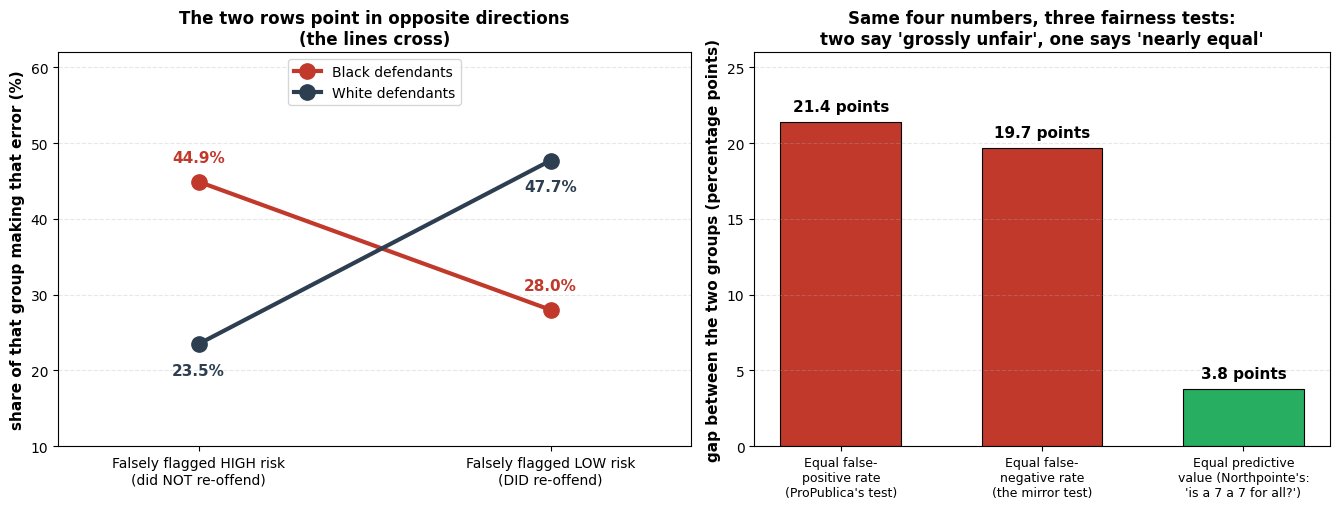

Of everyone COMPAS flagged high risk, the share who actually re-offended (PPV):
  Black : base rate 51%, FPR 44.9%, FNR 28.0%  ->  PPV = 62.5%
  White : base rate 39%, FPR 23.5%, FNR 47.7%  ->  PPV = 58.7%

  gap in false-positive rate : 21.4 points  (Black higher)
  gap in false-negative rate : 19.7 points  (white higher)
  gap in predictive value    : 3.8 points  (nearly equal)

Using a 52% base rate instead of 51% for Black defendants: PPV = 63.5% (gap 4.7 points).
The conclusion - error rates far apart, predictive value close together - does not move.


In [3]:
# Step 2b: Plot the four published ProPublica error rates, and the gap each fairness
#          definition produces from those same four numbers.
# WHY this figure: the whole COMPAS argument turns on the fact that BOTH sides were right.
# You cannot see that in a table of four percentages; you can see it immediately once the
# error rates and the calibration are put on the same page.

# --- The published numbers (ProPublica, Machine Bias, 2016; Broward County 2013-2014) ----
# These are the exact four percentages from the case table at the top of this notebook.
FPR = {"Black": 44.9, "White": 23.5}   # falsely flagged HIGH risk, did not re-offend
FNR = {"Black": 28.0, "White": 47.7}   # falsely flagged LOW risk, did re-offend

# Two-year re-arrest base rate in the same Broward sample. Reported as ~51% (Black) and
# ~39% (white) by Chouldechova (2017, Table 1); ProPublica's own methodology write-up gives
# 52% and 39%. We use 51/39 and check below that 52/39 does not change the conclusion.
BASE = {"Black": 0.51, "White": 0.39}


def ppv(p, fpr, fnr):
    """Positive predictive value implied by a base rate and the two error rates.

    Of everyone the tool flags high risk, what share actually re-offends?
    Derived from the definitions: the flagged group is p*(1-FNR) true positives plus
    (1-p)*FPR false ones. This is the quantity Northpointe called 'calibration'.
    """
    tp = p * (1 - fnr)                 # correctly flagged, and did re-offend
    fp = (1 - p) * fpr                 # wrongly flagged, and did not
    return 100 * tp / (tp + fp)


PPV = {g: ppv(BASE[g], FPR[g] / 100, FNR[g] / 100) for g in ("Black", "White")}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.2),
                               gridspec_kw={"width_ratios": [1.1, 1]})
COL = {"Black": "#c0392b", "White": "#2c3e50"}

# ---------------- LEFT: the two rows of the table, as two lines that cross --------------
# A slope chart, not bars: the claim in the text is about DIRECTION ("the two rows point in
# opposite directions"), and a line has a direction while a bar does not.
xs = [0, 1]
for g in ("Black", "White"):
    ys = [FPR[g], FNR[g]]
    axL.plot(xs, ys, "-o", color=COL[g], linewidth=3, markersize=11,
             label=g + " defendants")
    for x, y in zip(xs, ys):
        axL.annotate("%.1f%%" % y, (x, y), textcoords="offset points",
                     xytext=(0, 14 if g == "Black" else -22), ha="center",
                     fontsize=11, fontweight="bold", color=COL[g])
axL.set_xticks(xs)
axL.set_xticklabels(["Falsely flagged HIGH risk\n(did NOT re-offend)",
                     "Falsely flagged LOW risk\n(DID re-offend)"], fontsize=10)
axL.set_xlim(-0.4, 1.4)
axL.set_ylim(10, 62)
axL.set_ylabel("share of that group making that error (%)", fontsize=11, fontweight="bold")
axL.set_title("The two rows point in opposite directions\n(the lines cross)",
              fontsize=12, fontweight="bold")
axL.legend(fontsize=10, loc="upper center")
axL.grid(axis="y", alpha=0.3, linestyle="--")

# ---------------- RIGHT: how big the gap is, per definition of fairness -----------------
defs = ["Equal false-\npositive rate\n(ProPublica's test)",
        "Equal false-\nnegative rate\n(the mirror test)",
        "Equal predictive\nvalue (Northpointe's:\n'is a 7 a 7 for all?')"]
gaps = [FPR["Black"] - FPR["White"], FNR["White"] - FNR["Black"], PPV["Black"] - PPV["White"]]
bars = axR.bar(defs, gaps, color=["#c0392b", "#c0392b", "#27ae60"],
               edgecolor="black", linewidth=0.8, width=0.6)
for b, g in zip(bars, gaps):
    axR.text(b.get_x() + b.get_width() / 2, g + 0.7, "%.1f points" % g,
             ha="center", fontsize=11, fontweight="bold")
axR.set_ylim(0, 26)
axR.set_ylabel("gap between the two groups (percentage points)",
               fontsize=11, fontweight="bold")
axR.set_title("Same four numbers, three fairness tests:\ntwo say 'grossly unfair', one says 'nearly equal'",
              fontsize=12, fontweight="bold")
axR.tick_params(axis="x", labelsize=9)
axR.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

# ---- Print the arithmetic so every number in the figure can be checked by hand ---------
print("Of everyone COMPAS flagged high risk, the share who actually re-offended (PPV):")
for g in ("Black", "White"):
    print("  %-6s: base rate %.0f%%, FPR %.1f%%, FNR %.1f%%  ->  PPV = %.1f%%"
          % (g, 100 * BASE[g], FPR[g], FNR[g], PPV[g]))
print()
print("  gap in false-positive rate : %.1f points  (Black higher)" % (FPR["Black"] - FPR["White"]))
print("  gap in false-negative rate : %.1f points  (white higher)" % (FNR["White"] - FNR["Black"]))
print("  gap in predictive value    : %.1f points  (nearly equal)" % (PPV["Black"] - PPV["White"]))

# Robustness check: ProPublica's own write-up gives a 52% base rate rather than 51%.
# Confirm the conclusion does not depend on which of the two published figures we take.
alt = ppv(0.52, FPR["Black"] / 100, FNR["Black"] / 100)
print()
print("Using a 52%% base rate instead of 51%% for Black defendants: PPV = %.1f%% (gap %.1f points)."
      % (alt, alt - PPV["White"]))
print("The conclusion - error rates far apart, predictive value close together - does not move.")

### 👁️ Read the figure

**Left panel — what you should see.** Two axes, two lines, and they **cross**. The dark-red
line (Black defendants) starts high on the left at **44.9 %** false-positive rate and falls to
**28.0 %** on the right. The navy line (white defendants) starts low at **23.5 %** and rises
to **47.7 %**. One group absorbs the false alarms; the other absorbs the missed cases. That
crossing *is* ProPublica's finding, and it is the only thing in this notebook you can check
against a published source line by line.

**Right panel — what you should see.** Three bars measuring the *same four numbers* against
three different definitions of fairness. Two red bars around **20 points** — the tool fails
badly on equal error rates. One green bar at **under 4 points** — the tool passes on equal
predictive value, which is precisely the test Northpointe applied when it said COMPAS was
calibrated. The printed output derives that green bar from the base rates so you can redo
the arithmetic yourself.

**What it proves.** Nobody in the COMPAS argument was lying. ProPublica measured the red
bars; Northpointe measured the green one; both were reading the same defendants. The dispute
was never about arithmetic. It was about **which bar a court is entitled to look at** — and
the next figure shows why you cannot have all three at once.

---

## 🎞️ Why you are not allowed to refuse to choose — a five-frame storyboard

The case description claimed something stronger than "COMPAS was unfair": it claimed that
Chouldechova (2017) and Kleinberg et al. (2016) **proved** that no classifier can satisfy
calibration and equal error rates at once when two groups have different base rates.

That is a claim you can watch happen. The five frames below all describe an *imaginary,
perfectly behaved* tool — one that is equally calibrated for both groups and misses exactly
the same share of re-offenders in both. The only thing that changes from frame to frame is
**the gap between the two groups' base rates**, sliding from "identical" to the roughly
51 % / 39 % actually observed in Broward. Watch the false-positive rate come apart on its
own.

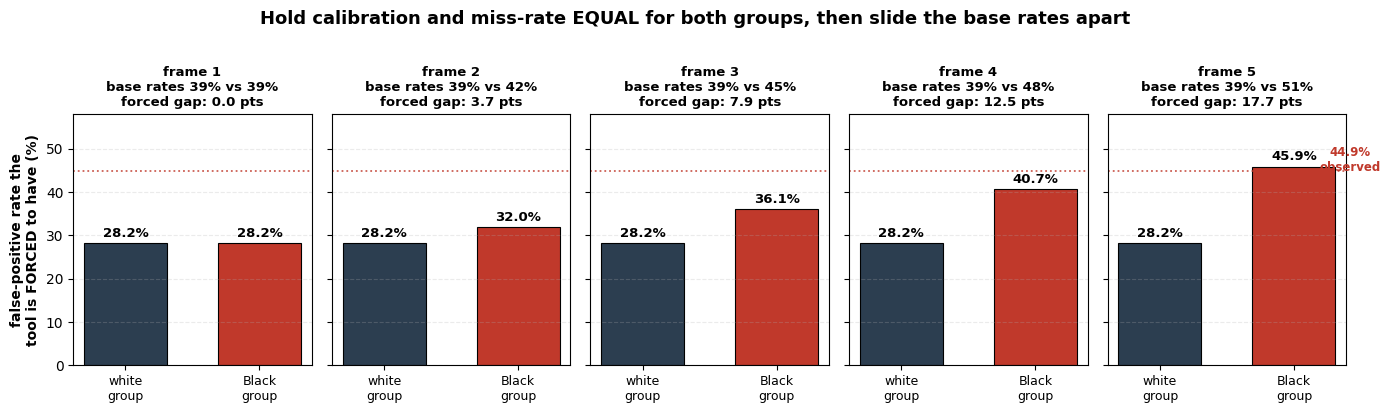

Both groups pinned to PPV = 62% and FNR = 28% in every frame.

frame   base rate   base rate      FPR      FPR   forced gap
          (white)     (Black)  (white)  (Black)     (points)
    1         39%         39%    28.2%    28.2%          0.0
    2         39%         42%    28.2%    32.0%          3.7
    3         39%         45%    28.2%    36.1%          7.9
    4         39%         48%    28.2%    40.7%         12.5
    5         39%         51%    28.2%    45.9%         17.7

Frame 1: identical base rates -> identical error rates. Fairness is free.
Frame 5: the Broward base rates -> a 17.7-point false-positive gap, produced by a
         tool that is doing nothing wrong by either group.

The gap ProPublica measured was 21.4 points. Most of it is what the arithmetic
demands the moment you insist on equal calibration. That is not extra malice, and
it is not an excuse either - it is the choice the courts were never told about.


In [4]:
# Step 2c: Frame grid - slide the base-rate gap and watch equal error rates become impossible
# WHY a frame grid and not one curve: the claim is about a PROCESS ("as the base rates move
# apart, the false-positive rates are forced apart"). Five snapshots of the same axes, read
# left to right, show that movement - and unlike an animation, every frame is on the page.

# The identity behind every frame (Chouldechova 2017, rearranged from the definitions):
#     FPR = [ p / (1 - p) ] * [ (1 - PPV) / PPV ] * (1 - FNR)
# Read it as: once you fix how calibrated the tool is (PPV) and how many re-offenders it
# misses (FNR), the base rate p ALONE decides the false-positive rate. There is no freedom
# left over to spend on making the two groups' false-positive rates match.

FIX_PPV = 0.62   # both groups equally calibrated: 62% of those flagged high risk do re-offend
FIX_FNR = 0.28   # both groups missed at exactly the same rate


def forced_fpr(p, ppv_=FIX_PPV, fnr_=FIX_FNR):
    """The false-positive rate a base rate p FORCES, once PPV and FNR are pinned equal."""
    return 100 * (p / (1 - p)) * ((1 - ppv_) / ppv_) * (1 - fnr_)


p_white = 0.39                                    # held fixed across all five frames
p_black_frames = [0.39, 0.42, 0.45, 0.48, 0.51]   # slides from 'identical' to 'as observed'

fig, axes = plt.subplots(1, len(p_black_frames), figsize=(14, 4.0), sharey=True)
for k, (ax, pb) in enumerate(zip(axes, p_black_frames), start=1):
    vals = [forced_fpr(p_white), forced_fpr(pb)]
    ax.bar(["white\ngroup", "Black\ngroup"], vals, color=["#2c3e50", "#c0392b"],
           edgecolor="black", linewidth=0.8, width=0.62)
    for x, v in enumerate(vals):
        ax.text(x, v + 1.4, "%.1f%%" % v, ha="center", fontsize=9.5, fontweight="bold")
    # Faint reference: the false-positive rate COMPAS actually showed for Black defendants.
    ax.axhline(44.9, color="#c0392b", linestyle=":", linewidth=1.3, alpha=0.8)
    ax.set_ylim(0, 58)
    ax.set_title("frame %d\nbase rates %.0f%% vs %.0f%%\nforced gap: %.1f pts"
                 % (k, 100 * p_white, 100 * pb, vals[1] - vals[0]),
                 fontsize=9.5, fontweight="bold")
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.tick_params(axis="x", labelsize=9)
axes[0].set_ylabel("false-positive rate the\ntool is FORCED to have (%)",
                   fontsize=10, fontweight="bold")
axes[-1].text(1.42, 47.5, "44.9%\nobserved", fontsize=8.5, color="#c0392b",
              va="center", ha="center", fontweight="bold")
fig.suptitle("Hold calibration and miss-rate EQUAL for both groups, then slide the base rates apart",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ---- The step table that goes with the frames -------------------------------------------
print("Both groups pinned to PPV = %.0f%% and FNR = %.0f%% in every frame."
      % (100 * FIX_PPV, 100 * FIX_FNR))
print()
print("frame   base rate   base rate      FPR      FPR   forced gap")
print("          (white)     (Black)  (white)  (Black)     (points)")
for k, pb in enumerate(p_black_frames, start=1):
    fw, fb = forced_fpr(p_white), forced_fpr(pb)
    print("%5d   %8.0f%%   %8.0f%%  %6.1f%%  %6.1f%%   %10.1f"
          % (k, 100 * p_white, 100 * pb, fw, fb, fb - fw))
print()
print("Frame 1: identical base rates -> identical error rates. Fairness is free.")
print("Frame 5: the Broward base rates -> a %.1f-point false-positive gap, produced by a"
      % (forced_fpr(0.51) - forced_fpr(0.39)))
print("         tool that is doing nothing wrong by either group.")
print()
print("The gap ProPublica measured was 21.4 points. Most of it is what the arithmetic")
print("demands the moment you insist on equal calibration. That is not extra malice, and")
print("it is not an excuse either - it is the choice the courts were never told about.")

### 👁️ Read the storyboard

**What you should see.** Five panels sharing one y-axis. In **frame 1** the two bars are the
same height (28.2 % each) and the printed gap is **0.0 points** — when the base rates are
identical, a calibrated tool is automatically equal on errors too, and there is nothing to
argue about. Moving right, the navy bar never moves — the white group's base rate is held at
39 % in every frame — while the dark-red bar climbs, frame by frame, to **45.9 %** in frame 5.
The dotted red line across all five panels marks the **44.9 %** false-positive rate COMPAS
actually showed for Black defendants; the red bar rises to meet it only in the last frame.

**What it proves.** Nothing in these frames is unfair on purpose. Every frame describes a
tool that is *perfectly* calibrated for both groups and misses re-offenders at exactly the
same rate in both. The false-positive gap still opens up, driven by the base-rate gap alone,
and by frame 5 it is **17.7 points** of the 21.4 points ProPublica measured. That is
Chouldechova's impossibility result, drawn: with unequal base rates you may have equal
predictive value *or* equal error rates, and choosing one is choosing which group absorbs
the harm.

**Why this matters for the ethics, not just the statistics.** It removes the comfortable
verdict. "Fix the algorithm" is not available; there is no version of this tool that passes
every fairness test at once. What was available — and what nobody did — was to state in
public which error the court had decided to minimise, and why. That is what question 1 in
the 💬 Discuss section asks you to decide, and now you have the arithmetic to defend an
answer.

---

## Part 3: Visualizing Ethical Issues

### 📚 Prerequisites (What You Need First)
- ✅ **Case analysis** (from Part 2) - Understanding the ethical issues
- ✅ **Visualization libraries** (from Part 1) - Understanding matplotlib

### 🔗 Relationship: What This Builds On
This visualizes the ethical issues we identified!
- Builds on: Ethical issues analysis
- Shows: Relative severity of different issues

### 📖 The Story
**Before visualization**: We have a list of issues but can't easily compare them.
**After visualization**: We can see which issues are most severe and need immediate attention!

---

## Step 3: Visualize Ethical Issues

**BEFORE**: We have a list of ethical issues but can't easily see their relative severity.

**AFTER**: We'll create a chart showing the severity of each ethical issue!

**Why visualize?** Visual representation helps us:
- See which issues are most severe
- Prioritize which problems to address first
- Understand the overall ethical landscape
> **Read the chart's units before you read the chart.** The severity scores below are
> **author-assigned judgments** chosen to structure a discussion - they are not
> measurements of anything. The *facts* of the COMPAS case are in the fact sheet above
> (ProPublica, 2016); the *measured* bias numbers in this course arrive in Unit 2, where
> you transcribe a published audit table and compute disparities on a real dataset yourself.


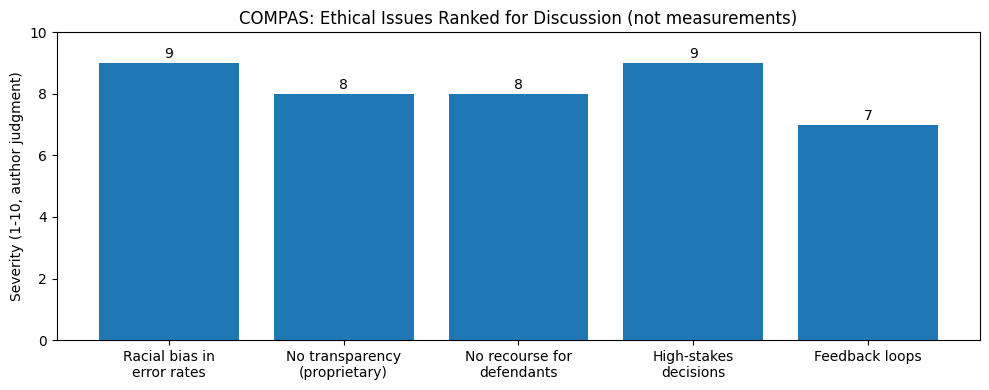

These scores are the course authors' judgment, offered to start an argument -
disagree with them and defend your own ranking; that is the exercise.
The two we rank highest: racial bias in error rates, and the stakes of the
decisions the scores influence.

What is NOT a judgment call: the four measured error rates plotted above,
and the disparities you will measure yourself on real data in Unit 2.


In [5]:
# Step 3: Rank the ethical issues of the COMPAS case for discussion
# WHY a chart of judgments, clearly labelled as such: prioritising issues is a
# human decision, and being explicit that these are opinions - not measurements -
# is itself part of the ethics we are teaching. Unit 2 does the measuring.

issues = ["Racial bias in\nerror rates", "No transparency\n(proprietary)",
          "No recourse for\ndefendants", "High-stakes\ndecisions", "Feedback loops"]
severity = [9, 8, 8, 9, 7]  # AUTHOR-ASSIGNED discussion scores (1-10), not measurements

# Draw one bar per ethical issue so the relative ranking is visible side by side.
plt.figure(figsize=(10, 4))
bars = plt.bar(issues, severity)
plt.ylim(0, 10)
plt.ylabel("Severity (1-10, author judgment)")
plt.title("COMPAS: Ethical Issues Ranked for Discussion (not measurements)")
# Label each bar with its exact score so readers do not have to estimate from bar height.
for b, s in zip(bars, severity):
    plt.text(b.get_x() + b.get_width()/2, s + 0.15, str(s), ha="center")
plt.tight_layout()
plt.show()

print("These scores are the course authors' judgment, offered to start an argument -")
print("disagree with them and defend your own ranking; that is the exercise.")
print("The two we rank highest: racial bias in error rates, and the stakes of the")
print("decisions the scores influence.")
print("\nWhat is NOT a judgment call: the four measured error rates plotted above,")
print("and the disparities you will measure yourself on real data in Unit 2.")


## Part 4: Applying Ethical Frameworks

### 📚 Prerequisites (What You Need First)
- ✅ **Case analysis** (from Part 2) - Understanding the ethical issues
- ✅ **Ethical frameworks** (from Example 1) - Understanding different perspectives

### 🔗 Relationship: What This Builds On
This applies the frameworks we learned to the COMPAS case!
- Builds on: Ethical frameworks knowledge, case study analysis
- Shows: How different frameworks evaluate the same case

### 📖 The Story
**Before framework application**: We identified issues but haven't analyzed them through different ethical lenses.
**After framework application**: We see how each framework evaluates COMPAS and why they all find it unethical!

---

## Step 4: Apply Ethical Frameworks

**BEFORE**: We identified ethical issues but haven't analyzed them through different ethical frameworks.

**AFTER**: We'll see how each ethical framework evaluates the COMPAS case!

**Why apply multiple frameworks?** Different frameworks give different perspectives:
- Utilitarianism: Focuses on overall harm/benefit
- Deontology: Focuses on moral rules and duties
- Rights-Based: Focuses on individual rights
- Virtue Ethics: Focuses on character and virtues

In [6]:
# Step 4: Apply ethical frameworks to the COMPAS case
# This shows how different frameworks evaluate the same ethical problem

# Record each framework's verdict on COMPAS with the reasoning behind it.
# When frameworks that usually disagree all say FAILS, the conclusion is robust.
frameworks = {
    "Utilitarianism (outcomes)":
        "FAILS - the harm of unfair detention for misclassified defendants "
        "outweighs efficiency gains for courts.",
    "Deontology (duties/rights)":
        "FAILS - due process requires that people can examine and challenge "
        "evidence against them; a secret score violates that duty.",
    "Virtue ethics (character)":
        "FAILS - deploying an opaque, biased system does not reflect honesty, "
        "justice or prudence on the part of its operators.",
}

print("=" * 80)
print("APPLYING ETHICAL FRAMEWORKS TO COMPAS")
print("=" * 80)
# Print each framework's verdict - note that all three converge on the same answer.
for fw, verdict in frameworks.items():
    print(f"\n{fw}:")
    print(f"  {verdict}")

print()
print("All three frameworks converge on the same conclusion - a strong signal")
print("that the deployment was ethically unsound.")

APPLYING ETHICAL FRAMEWORKS TO COMPAS

Utilitarianism (outcomes):
  FAILS - the harm of unfair detention for misclassified defendants outweighs efficiency gains for courts.

Deontology (duties/rights):
  FAILS - due process requires that people can examine and challenge evidence against them; a secret score violates that duty.

Virtue ethics (character):
  FAILS - deploying an opaque, biased system does not reflect honesty, justice or prudence on the part of its operators.

All three frameworks converge on the same conclusion - a strong signal
that the deployment was ethically unsound.


## Part 5: Lessons Learned

### 📚 Prerequisites (What You Need First)
- ✅ **Case analysis** (from Part 2) - Understanding the ethical issues
- ✅ **Framework analysis** (from Part 4) - Understanding how frameworks evaluate the case

### 🔗 Relationship: What This Builds On
This extracts lessons from the COMPAS case to prevent future problems!
- Builds on: Complete case study analysis
- Shows: How to learn from ethical failures

### 📖 The Story
**Before lessons learned**: We analyzed the case but haven't extracted actionable lessons.
**After lessons learned**: We know what to do differently to prevent similar ethical failures!

---

## Step 5: Extract Lessons Learned

**BEFORE**: We've analyzed the case but haven't identified what we can learn from it.

**AFTER**: We'll extract key lessons that help us build more ethical AI systems!

**Why extract lessons?** Learning from failures helps us:
- Avoid making the same mistakes
- Build better systems in the future
- Understand best practices for ethical AI

In [7]:
# Step 5: Extract lessons learned from the COMPAS case
# This identifies key takeaways that help us build better AI systems

# Turn the case analysis into actionable engineering lessons -
# each one maps to a later unit of this course (bias testing, transparency, recourse, auditing).
lessons = [
    {"lesson": "Test for bias before deployment",
     "description": "Comprehensive bias testing across groups is essential to identify problems early"},
    {"lesson": "Transparency is crucial",
     "description": "High-stakes algorithms need to be examinable by the people they affect"},
    {"lesson": "Provide recourse",
     "description": "People must be able to challenge automated decisions about them"},
    {"lesson": "Match rigor to stakes",
     "description": "The higher the stakes of a decision, the higher the evidence bar before automating it"},
    {"lesson": "Monitor after deployment",
     "description": "Bias can emerge or worsen in production - auditing is continuous, not one-off"},
]

print("=" * 80)
print("LESSONS LEARNED FROM COMPAS")
print("=" * 80)
# Print the lessons as a numbered checklist students can reuse on any AI project.
for i, item in enumerate(lessons, 1):
    print(f"\n{i}. {item['lesson']}")
    print(f"   {item['description']}")

LESSONS LEARNED FROM COMPAS

1. Test for bias before deployment
   Comprehensive bias testing across groups is essential to identify problems early

2. Transparency is crucial
   High-stakes algorithms need to be examinable by the people they affect

3. Provide recourse
   People must be able to challenge automated decisions about them

4. Match rigor to stakes
   The higher the stakes of a decision, the higher the evidence bar before automating it

5. Monitor after deployment
   Bias can emerge or worsen in production - auditing is continuous, not one-off


## 💬 Discuss

The cell above printed **three frameworks converging on FAILS** and called that "a strong
signal that the deployment was ethically unsound". Test that claim rather than accepting it.

1. **Was it unethical, or was it an undeclared choice?** Northpointe's calibration defence
   was mathematically correct, and Chouldechova's impossibility result says COMPAS *could
   not* have satisfied both fairness definitions. So which verdict do you actually hold:
   that deploying COMPAS was unethical, or that it was **a defensible choice of which error
   to minimise, made without ever telling the courts that a choice was being made**? These
   are different findings and they imply completely different fixes — one bans the tool, the
   other bans the silence.
2. **Your turn to choose the error.** You are advising a court in your own country that is
   considering a risk tool for pre-trial release. Which error do you tell the judges to
   minimise: releasing someone who then re-offends, or detaining someone who would not have?
   Name the group that pays for your choice, and say plainly why that cost is acceptable.
   (If your answer is "neither", you have chosen the status quo — say who pays for *that*.)
3. **Is a warning label due process?** In *State v. Loomis* (Wisconsin Supreme Court, 2016)
   the court permitted COMPAS scores at sentencing even though the algorithm is a trade
   secret the defendant cannot examine — provided the score came with a written caution.
   Is that sufficient? What would you require instead, knowing that a full-disclosure
   requirement may simply mean no vendor sells to you at all, and the judge decides
   unaided?


## 🎯 Summary: What We Learned

**BEFORE this notebook**: We knew ethical frameworks and decision-making processes but hadn't applied them to real cases.

**AFTER this notebook**: We can:
- ✅ Analyze real-world AI ethics case studies (like COMPAS)
- ✅ Identify ethical issues using multiple frameworks
- ✅ Evaluate the severity of ethical problems
- ✅ Apply ethical frameworks to real scenarios
- ✅ Visualize ethical issues for better understanding
- ✅ Extract lessons learned to prevent future problems

### Key Takeaways

1. **Real-World Impact**: AI systems can have serious ethical issues that affect real people's lives
2. **Multiple Perspectives**: Different ethical frameworks help identify different types of problems
3. **Severity Matters**: Not all ethical issues are equal - some are more critical than others
4. **Learning from Failures**: Case studies provide valuable lessons for future development
5. **Systematic Analysis**: Following a structured approach ensures comprehensive ethical evaluation

---

## ➡️ Transition to Unit 2: Bias and Justice

### The Problem We Discovered

In analyzing the COMPAS case, we identified **bias** as a major ethical issue:
- Higher false positive rates for Black defendants
- Higher false negative rates for White defendants
- Racial bias in risk predictions

**The Problem**: We understand ethics foundations, but **AI systems show bias. How do we detect it?**

We've learned:
- ✅ How to identify ethical issues (frameworks)
- ✅ How to analyze cases systematically (decision-making)
- ✅ How bias manifests in real systems (COMPAS case)

**But we haven't learned:**
- ❌ How to **detect** bias in AI systems
- ❌ How to **measure** bias quantitatively
- ❌ How to **mitigate** bias in AI systems

### The Solution: Unit 2 - Bias and Justice

**Next Unit**: `unit2-bias-justice/`
- Learn bias detection metrics and tools
- Understand bias mitigation techniques
- Practice detecting and fixing bias in AI systems

**This addresses the specific problem** we discovered in the COMPAS case study!

---

**Congratulations!** 🎉 You've completed Unit 1 and are ready to dive deep into bias detection and mitigation!

In [8]:
# Closing takeaway
# Why this matters: it connects one real case to every failure mode the rest of the course teaches.
print("=" * 80)
print("CLOSING TAKEAWAY")
print("=" * 80)
print()
print("COMPAS shows why AI ethics is practical, not abstract: a model that")
print("performs 'well' on average can still fail specific groups, in secret,")
print("at life-changing stakes. Every later unit in this course (bias and")
print("fairness, privacy, interpretability, governance) addresses one of the")
print("failure modes you saw in this single case.")

CLOSING TAKEAWAY

COMPAS shows why AI ethics is practical, not abstract: a model that
performs 'well' on average can still fail specific groups, in secret,
at life-changing stakes. Every later unit in this course (bias and
fairness, privacy, interpretability, governance) addresses one of the
failure modes you saw in this single case.


## ⚠️ Where this breaks

Case-study analysis is a teaching instrument, and it has known failure modes. Four that
apply to the analysis you just performed.

- **Hindsight makes every decision look obvious.** We read COMPAS with the audit already
  published. The people procuring it in 2013 had a vendor validation study and no
  ProPublica. If your analysis of a past failure does not state what a *reasonable* person
  could have known **at the time**, it is training smugness rather than judgement.
- **One case, one county, one label definition.** ProPublica's figures are Broward County,
  2013–2014, with a two-year window and "re-offend" operationalised as **re-arrest**. Arrest
  is itself distributed unevenly by policing, so the ground-truth label carries some of the
  very bias the tool stands accused of. Do not quote 44.9 % as a property of COMPAS
  everywhere, or of risk assessment in general.
- **One chart in this notebook is opinion, and charts look like facts.** The *severity*
  bar chart ranks ethical issues on author-assigned scores, exactly as its caption warns.
  Keep it apart from the two charts before it: the crossing error-rate lines are ProPublica's
  published measurements, and the five-frame storyboard is arithmetic you can redo by hand.
  Three figures, three completely different epistemic statuses — check the axis label before
  you quote any of them.
- **Converging frameworks may converge because we chose the case.** All three frameworks
  agree here — good pedagogy, weak evidence. The genuinely hard cases are the ones where a
  system measurably reduces total harm while concentrating it on one group, and those are
  precisely the cases where frameworks split. This notebook does not train you on them.

**When to reach for something else:** if the question is whether *your* system is biased, no
case study will answer it. Compute per-group error rates on your own data. That is Unit 2,
Notebook 01, and it begins by loading a CSV.

**The same pattern, other domains.** A single audit exposing an error rate nobody had
disaggregated is the recurring shape: *Gender Shades* (2018) did it to commercial face
classifiers, Obermeyer et al. (*Science*, 2019) did it to a US health-risk algorithm used on
~200 million people a year, and the Dutch tax authority's fraud model (Unit 4) was exposed
the same way. In each, the aggregate metric was fine and the subgroup metric was not.


## 📚 References

1. Angwin, J., Larson, J., Mattu, S. & Kirchner, L. (2016). *Machine Bias*. ProPublica. <https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing>
2. Buolamwini, J. & Gebru, T. (2018). *Gender Shades: Intersectional Accuracy Disparities in Commercial Gender Classification*. FAT* 2018, PMLR 81. <https://proceedings.mlr.press/v81/buolamwini18a.html>
3. Raji, I. D., Smart, A., White, R. N., et al. (2020). *Closing the AI Accountability Gap: Defining an End-to-End Framework for Internal Algorithmic Auditing*. FAT* 2020. <https://arxiv.org/abs/2001.00973>